In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

In [2]:
manual_db = pl.read_parquet(r".database\manual_detection_database.parquet")
auto_db = dp.combined_mask_no_merge.filter(pl.col("face") == "posx").collect()

manual_db

i,j,manual_detect_boulder_id,face
i32,i32,u32,str
7661,5626,7883757,"""posx"""
7661,5627,7883757,"""posx"""
7661,5628,7883757,"""posx"""
7661,5629,7883757,"""posx"""
7661,5630,7883757,"""posx"""
…,…,…,…
40,2454,10549449,"""posx"""
40,2455,10549449,"""posx"""
40,2456,10549449,"""posx"""


In [3]:
auto_db_agg = auto_db.group_by("row_id").agg(pl.len().alias("auto_boulder_size"), pl.col("lod_level").first())
manual_db_agg = manual_db.group_by("manual_detect_boulder_id").agg(pl.len().alias("manual_boulder_size"))

db_intersections = manual_db.join(
    auto_db,
    on=["i", "j"],
    how="inner",
).select("i", "j", "lod_level", "lod_code", "row_id", "manual_detect_boulder_id")

manual_db_agg

manual_detect_boulder_id,manual_boulder_size
u32,u32
12973782,55
1411612,58
559319,128
6612068,33423
16200577,31
…,…
16619481,43
2961614,87
7579290,72


In [4]:
db_intersections_agg = db_intersections.group_by("manual_detect_boulder_id", "row_id").agg(
    pl.len().alias("overlap"),
    pl.col("lod_level").first(),
    pl.col("lod_code").first()
)

db_jaccard = db_intersections_agg.join(
    auto_db_agg,
    on="row_id",
    how="left",
).join(
    manual_db_agg,
    on="manual_detect_boulder_id",
    how="left",
).with_columns(
    (
        pl.col("overlap") / (pl.col("auto_boulder_size") + pl.col("manual_boulder_size") - pl.col("overlap"))
    ).alias("Jaccard_index")
)

db_jaccard

manual_detect_boulder_id,row_id,overlap,lod_level,lod_code,auto_boulder_size,lod_level_right,manual_boulder_size,Jaccard_index
u32,u32,u32,u8,str,u32,u8,u32,f64
566518,17,1042,0,"""""",22016,0,68617,0.011631
6539471,499805,176,3,"""ACA""",176,3,65122,0.002703
6745427,518349,48,4,"""ACAB""",48,4,45229,0.001061
6539471,518414,56,4,"""ACAB""",56,4,65122,0.00086
6539471,518421,96,4,"""ACAB""",96,4,65122,0.001474
…,…,…,…,…,…,…,…,…
15234118,1943113,8285,2,"""CA""",8288,2,79858,0.103743
15234118,1943139,315,2,"""CA""",1264,2,79858,0.003898
7375019,1943148,4548,2,"""CA""",4720,2,11718,0.382506


In [5]:
db_jaccard_agg = (
    db_jaccard
    .group_by(["lod_level", "manual_detect_boulder_id"])
    .agg(
        pl.all().get(
            pl.col("Jaccard_index").arg_max()
        )
    )
).with_columns(
    (pl.col("manual_boulder_size") // (2 ** (8 - 2 * pl.col("lod_level")))).alias("viewport_size"),
    (pl.col("auto_boulder_size") / pl.col("manual_boulder_size")).alias("area_diff_factor")
)

db_jaccard_agg

lod_level,manual_detect_boulder_id,row_id,overlap,lod_code,auto_boulder_size,lod_level_right,manual_boulder_size,Jaccard_index,viewport_size,area_diff_factor
u8,u32,u32,u32,str,u32,u8,u32,f64,u32,f64
3,4600381,1629662,525,"""BCD""",552,3,663,0.76087,165,0.832579
4,16670981,386530,4103,"""ABCB""",4103,4,61075,0.06718,61075,0.06718
1,15489465,19821,41722,"""A""",41856,1,71542,0.582092,1117,0.585055
3,6745427,499744,3856,"""ACA""",3856,3,45229,0.085255,11307,0.085255
0,15528702,116,4120,"""""",4352,0,82774,0.049635,323,0.052577
…,…,…,…,…,…,…,…,…,…,…
3,8127167,2934392,1998,"""DAA""",2452,3,2170,0.761433,542,1.129954
3,14377489,1705854,680,"""BDA""",680,3,153423,0.004432,38355,0.004432
3,4869151,857486,14166,"""ADC""",14388,3,16785,0.832951,4196,0.857194


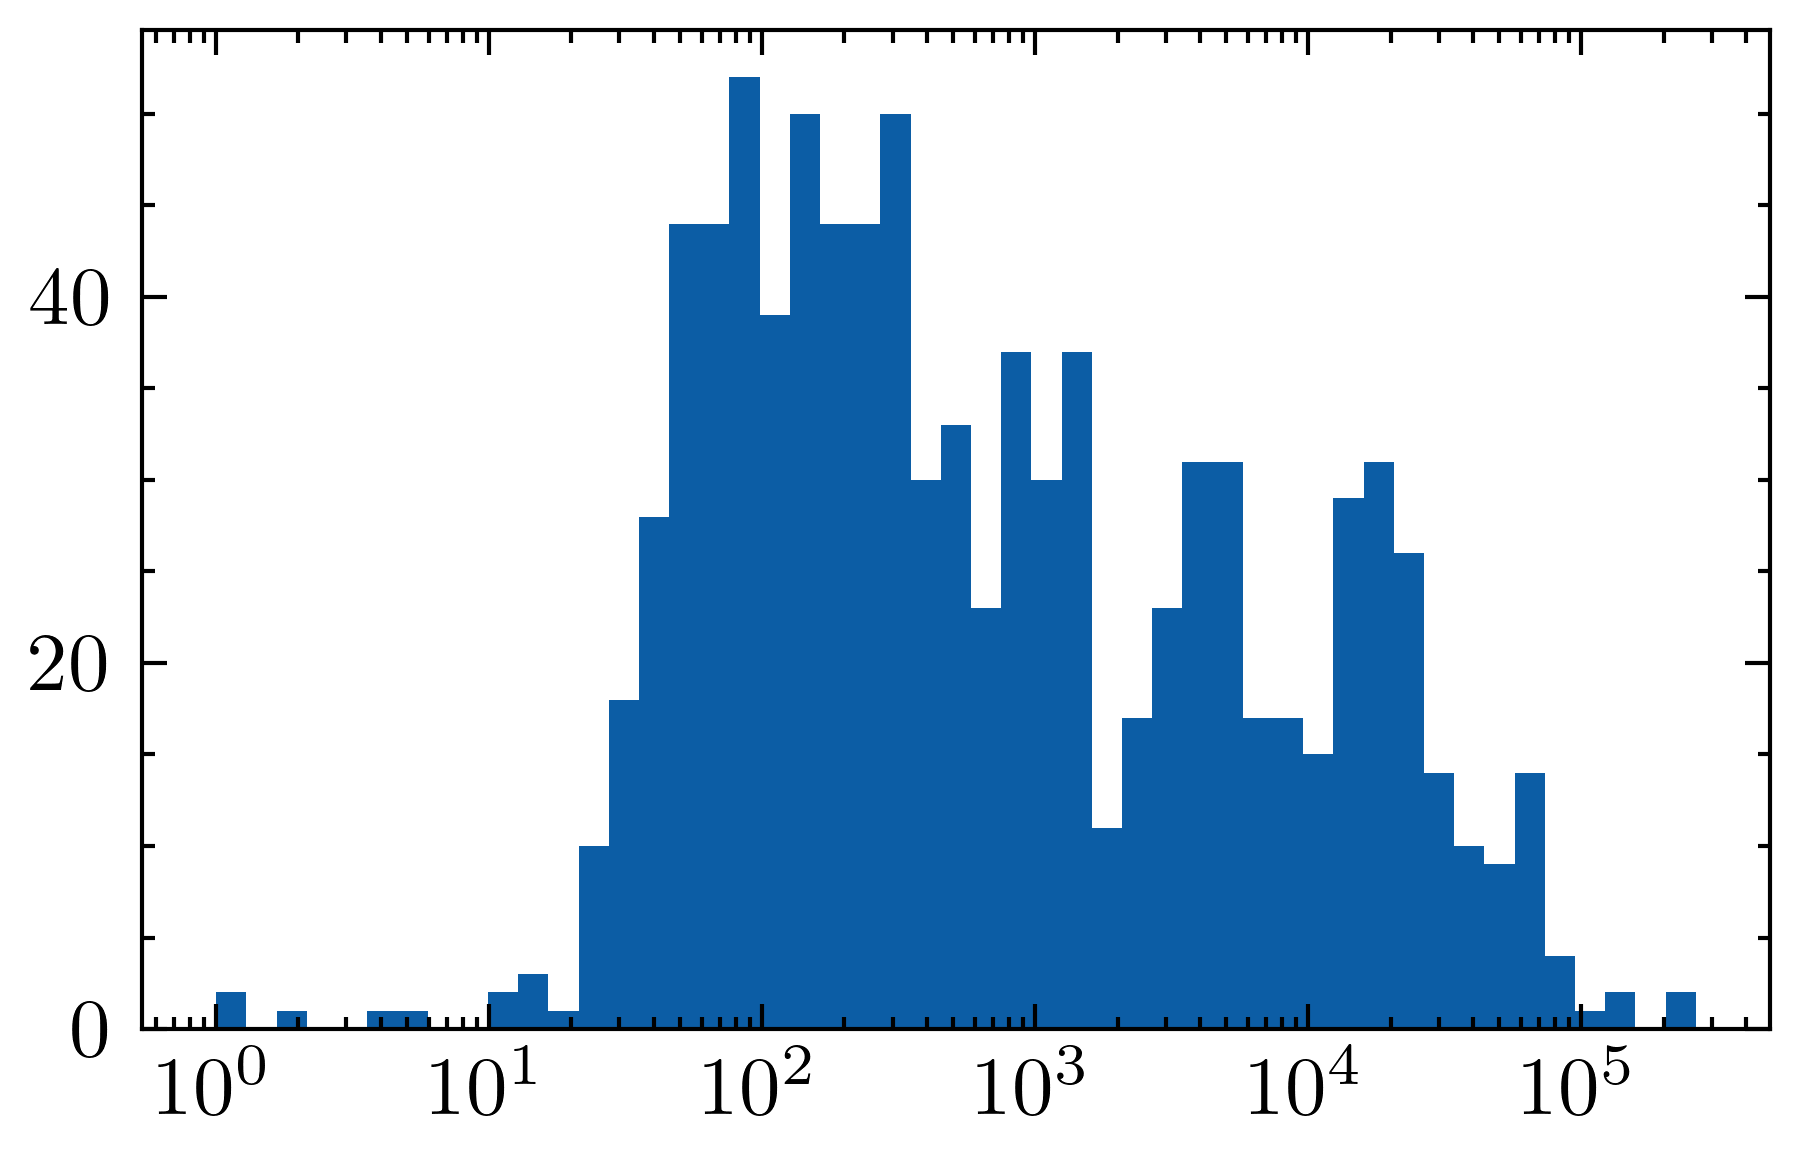

In [6]:
from boulder_statistics.analysis.sensitivity_model.KDE_bootstrapped_sensitivity_model import KDEBootstrappedSensitivityModel

db_jaccard_agg_filter = db_jaccard_agg.filter(pl.col("viewport_size") > 0)
alphas = db_jaccard_agg_filter["viewport_size"].to_numpy()
j = db_jaccard_agg_filter["Jaccard_index"].to_numpy()

_db = auto_db_agg.with_columns(
    (pl.col("auto_boulder_size") // (2 ** (8 - 2 * pl.col("lod_level")))).alias("rel_alphas")
    )

plt.hist(alphas, np.geomspace(1, 512*512, 50))
plt.xscale("log")
# plt.yscale("log")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 22 concurrent workers.
[Parallel(n_jobs=-1)]: Done  20 out of  20 | elapsed:    3.9s finished


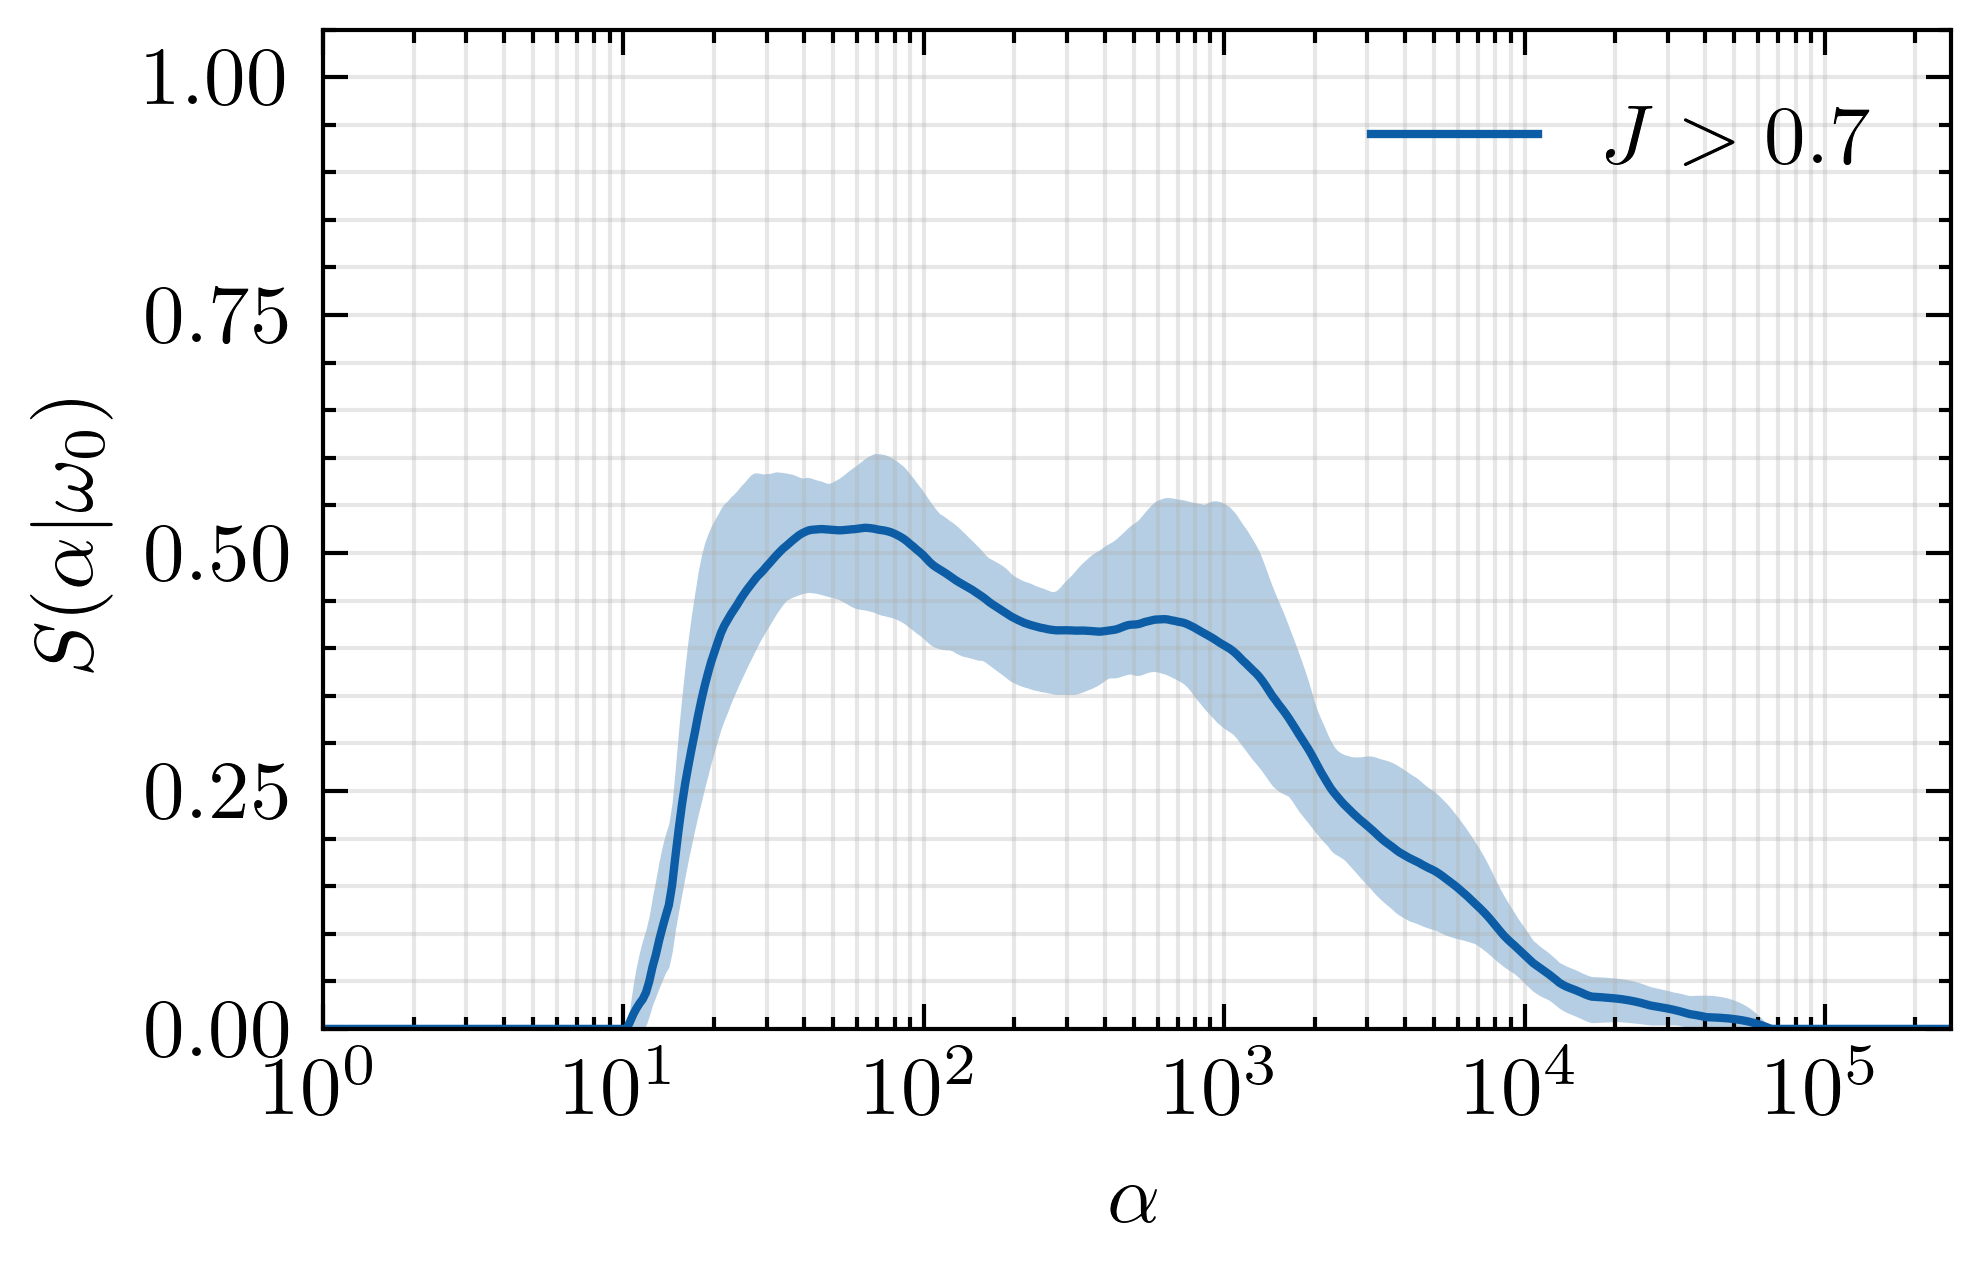

In [10]:
from joblib import Parallel, delayed

plotting_alphas = np.geomspace(1, 512**2, 500)
plotting_alphas_log = np.log(plotting_alphas)

# 200 for normal runs 5_000 for publication
numb_bootstrap = 20
plotting_alphas = np.geomspace(1, 512**2, 500)

for c_code, j_min_plot in enumerate([0.7]):
    sm = KDEBootstrappedSensitivityModel(dp.db_jaccard_agg, j_min_plot, bandwidth = 1)
    
    bootstrap_kde_data = np.array(
        Parallel(n_jobs=-1, verbose = 1)(
            delayed(sm.random_S_function(rng = np.random.default_rng()).function)(
                plotting_alphas
            )
            for _ in range(numb_bootstrap)
        )
    ).T

    # Statistics
    mean_pdf = bootstrap_kde_data.mean(axis=1)
    lower = np.percentile(bootstrap_kde_data, 2.5, axis=1)
    upper = np.percentile(bootstrap_kde_data, 97.5, axis=1)

    # 95% confidence interval
    plt.fill_between(
        plotting_alphas, lower, upper,
        alpha=0.3,
        color= f"C{c_code}",
        linewidth = 0
    )

    # Mean bootstrap KsDE
    plt.plot(plotting_alphas, mean_pdf, label=rf"$J > {j_min_plot}$", c = f"C{c_code}")

plt.xscale("log")
# plt.yscale("log")
plt.ylim(0, 1.05)
plt.xlim(1, 512*512)
plt.xlabel(r"$\alpha$")
plt.ylabel(r"$S(\alpha|\omega_0)$")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.savefig("S_from_manual_detection.png")
plt.show()

In [8]:
from joblib import Parallel, delayed

# 200 for normal runs 5_000 for publication
numb_bootstrap = 200
plotting_alphas = np.geomspace(1, 2 ** (2 * 4) * 512**2, 500)

def get_s_alpha_KDE(sm : KDEBootstrappedSensitivityModel, alpha_inputs: np.ndarray):
    func = sm.random_S_function(rng = np.random.default_rng()).function

    return 1 - np.prod([
            1 - func(alpha_inputs / (2 ** (2 * 4 - 2 * i))) for i in range(5)
        ], axis=0)

for c_code, j_min_plot in enumerate([0.7, 0.8]):
    sm = KDEBootstrappedSensitivityModel(dp.db_jaccard_agg, j_min_plot)
    
    bootstrap_kde_data = np.array(
        Parallel(n_jobs=-1, verbose = 1)(
            delayed(get_s_alpha_KDE)(
                sm,
                plotting_alphas,
            )
            for _ in range(numb_bootstrap)
        )
    ).T

    # Statistics
    mean_pdf = bootstrap_kde_data.mean(axis=1)
    min_pdf = bootstrap_kde_data.min(axis=1)
    lower = np.percentile(bootstrap_kde_data, 2.5, axis=1)
    upper = np.percentile(bootstrap_kde_data, 97.5, axis=1)

    print(f"J > {j_min_plot} Min PDF first non zero alpha", plotting_alphas[np.flatnonzero(min_pdf)[0]])

    # 95% confidence interval
    plt.fill_between(
        plotting_alphas, lower, upper,
        alpha=0.3,
        color= f"C{c_code}",
        linewidth = 0
    )

    # Mean bootstrap KsDE
    plt.plot(plotting_alphas, mean_pdf, label=rf"$J > {j_min_plot}$", c = f"C{c_code}")

plt.xscale("log")
plt.ylim(0, 1.05)
plt.xlim(1, plotting_alphas.max())
plt.xlabel(r"$\alpha$")
plt.ylabel(r"$S(\alpha)$")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.savefig("S_alpha_from_manual_detection.png")
plt.show()

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 22 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:    2.4s


KeyboardInterrupt: 

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# db_jaccard_agg_filter = db_jaccard_agg.filter(pl.col("viewport_size") > 0)
# alphas = db_jaccard_agg_filter["viewport_size"].to_numpy()
# j = db_jaccard_agg_filter["Jaccard_index"].to_numpy()

# auto_alphas = dp.boulder_agg_data.collect().with_columns(
#     (pl.col("alpha") // (2 ** (8 - 2 * pl.col("lod_level")))).alias("viewport_size")
# )["viewport_size"]

# plotting_alphas = np.geomspace(1, 512**2, 500)
# plotting_alphas_log = np.log(plotting_alphas)

# alphas_pass = alphas[j > 0.7]

# log_alphas = np.log(alphas)
# log_alphas_pass = np.log(alphas_pass)
# # log_auto_alphas = np.log(auto_alphas)

# log_alphas_kde = lambda alpha : len(log_alphas) * gaussian_kde(log_alphas)(np.log(alpha)) / alpha
# log_alphas_pass_kde = lambda alpha : len(log_alphas_pass) * gaussian_kde(log_alphas_pass)(np.log(alpha)) / alpha
# # log_auto_alphas_kde = lambda alpha : len(log_auto_alphas) * gaussian_kde(log_auto_alphas, bw_method = 0.01)(np.log(alpha)) / alpha

# plt.plot(plotting_alphas, log_alphas_kde(plotting_alphas), label="Total KDE")
# plt.plot(plotting_alphas, log_alphas_pass_kde(plotting_alphas), label="Success KDE")
# plt.xscale("log")
# plt.xlabel("Viewport size")
# plt.ylabel("Density")
# plt.legend()
# plt.show()